## Figure 4E
For each remote interval, find if it is chosen or no.

In [1]:
### For each remote arm representation, calculate the cos(animal_head, arm)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, ChangeofMindRemoteTheta

[2026-04-28 12:16:05,527][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[12:16:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:16:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:16:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[12:16:19][WARNING] Spyglass: Deprecation: this class has b

In [4]:
from spyglass.shijiegu.changeOfMind import nodes, color_by_rat
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess
from spyglass.shijiegu.changeOfMind_remote_interval import save_remote_animal, load_remote_animal

In [5]:
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().stop_export(**paper_key, analysis_id="ephys_future")

[12:16:20][WARNING] Spyglass: Export not in progress.


In [6]:
def return_save_name(animal, parameter_name, d1, d2, minimum_duration, min_posterior, proportion = 0.1, use_1d = 1):
    save_name = f'{animal.lower()}_{parameter_name}_{d1}_{d2}_t{minimum_duration}_minp{min_posterior}_p{proportion}_use1d{use_1d}_remoteGLM'
    return save_name

In [7]:
def make_result_df(model_fit, feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct"]):
    conf_int = model_fit.conf_int(alpha=0.05) # 95% confidence interval
    coefs = model_fit.params
    
    # Create a DataFrame for easier plotting (optional but good practice)
    results_df = pd.DataFrame({
            'coef': coefs,
            'lower_ci': conf_int[:, 0],
            'upper_ci': conf_int[:, 1]
        }, index=feature_names) # Adjust index names as per your model

    return results_df

In [8]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

In [9]:
proportion = 0.1
use_1d = 1
#parameter_name = "params_both_max_all_maze_2_state" 
parameter_name = "params_both_max_run_time_2_state"#"params_both_max_run_time_2_state" #"params_both_max_run_time_2_state"
minimum_duration = 0.02
min_posterior = 0.2

### For each animal, tally remote features and then do GLM

In [48]:
success = {}
for animal in ["molly", "eliot", "julio", "lewis", "klein"]:
    tally_dict = find_choice_animal(animal, list_of_days_animals[animal],
            parameter_name, minimum_duration = minimum_duration,
            min_posterior = min_posterior,  
            proportion = proportion)
    features_all, response_all, tally_dict, home_visit_all, home_replay_all, home_trial_info_all = trial_to_features(tally_dict, seq_animals[animal],
                                                   minimum_duration = minimum_duration, proportion = 0.1)
    # the 4 features are: "previous", "previously_rewarded", "future", "future_correct"
    
    data = {}
    data["features_all"] = features_all
    data["response_all"] = response_all
    data["tally_dict"] = tally_dict
    data["home_visit_all"] = home_visit_all
    data["home_replay_all"]= home_replay_all
    data["home_trial_info_all"] = home_trial_info_all
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    success[animal] = 1

lewis20240105_.nwb
lewis20240106_.nwb
lewis20240107_.nwb
lewis20240108_.nwb
lewis20240109_.nwb
lewis20240110_.nwb


[20:38:07][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-28 20:38:07,996][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2026-04-28 20:38:08,003][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2026-04-28 20:38:08,010][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2026-04-28 20:38:08,015][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a65



trial ID: 42
current_arm [6]
recent: 4
rat did not enter the future arm for at least 5 cm, excludeing this event
failed to find the immediate past


trial ID: lewis20240105_.nwb 02_Rev2Session1 50
current_arm [1]
recent: 4
immediate_past: 4
parsing multiple change of mind
trial ID: lewis20240105_.nwb 02_Rev2Session1 50
current_arm [6]
future: 3


trial ID: 62
current_arm [7]
recent: 3
rat did not enter the future arm for at least 5 cm, excludeing this event


trial ID: lewis20240105_.nwb 02_Rev2Session1 66
current_arm [2]
recent: 1
immediate_past: 2
parsing multiple change of mind
trial ID: lewis20240105_.nwb 02_Rev2Session1 66
current_arm [7]
future: 3
no recent on this trial


trial ID: lewis20240105_.nwb 02_Rev2Session1 70
current_arm [2]
recent: 4
immediate_past: 4
parsing multiple change of mind
trial ID: lewis20240105_.nwb 02_Rev2Session1 70
current_arm [7]
future: 1


trial ID: lewis20240105_.nwb 02_Rev2Session1 70
current_arm [1]
recent: 4
immediate_past: 2
parsing multiple c

[20:38:08][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-28 20:38:08,394][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2026-04-28 20:38:08,402][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2026-04-28 20:38:08,409][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2026-04-28 20:38:08,414][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8



trial ID: 5
current_arm [6]
recent: 4


trial ID: lewis20240105_.nwb 04_Rev2Session2 30
current_arm [1]
recent: 2
immediate_past: 3
parsing multiple change of mind
trial ID: lewis20240105_.nwb 04_Rev2Session2 30
current_arm [6]
future: 4


trial ID: lewis20240105_.nwb 04_Rev2Session2 43
current_arm [3]
recent: 1
immediate_past: 4
parsing multiple change of mind
trial ID: lewis20240105_.nwb 04_Rev2Session2 43
current_arm [8]
future: 2


trial ID: lewis20240105_.nwb 04_Rev2Session2 81
current_arm [1]
recent: 4
immediate_past: 3
parsing multiple change of mind
rat did not enter the future arm for at least 5 cm, excludeing this event
trial ID: lewis20240105_.nwb 04_Rev2Session2 81
current_arm [6]
future: 3


...



trial ID: lewis20240109_.nwb 08_Rev2Session4 16
current_arm [1]
recent: 4
immediate_past: 1
parsing multiple change of mind
trial ID: lewis20240109_.nwb 08_Rev2Session4 16
current_arm [6]
future: 3


trial ID: 20
current_arm [6]
recent: 4


trial ID: 11
current_arm [6]
recent: 3


trial ID: 15
current_arm [9]
recent: 3


trial ID: 16
current_arm [8]
recent: 2


trial ID: 19
current_arm [6]
recent: 4
no recent on this trial


trial ID: lewis20240110_.nwb 02_Rev2Session1 25
current_arm [1]
recent: 2
immediate_past: 2
parsing multiple change of mind
trial ID: lewis20240110_.nwb 02_Rev2Session1 25
current_arm [6]
future: 3


trial ID: lewis20240110_.nwb 02_Rev2Session1 25
current_arm [2]
recent: 2
immediate_past: 3
parsing multiple change of mind
trial ID: lewis20240110_.nwb 02_Rev2Session1 25
current_arm [7]
future: 4


trial ID: 48
current_arm [8]
recent: 1
no recent on this trial


trial ID: lewis20240110_.nwb 02_Rev2Session1 64
current_arm [4]
recent: 1
immediate_past: 1
parsing mult

[20:38:13][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-28 20:38:13,636][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2026-04-28 20:38:13,645][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2026-04-28 20:38:13,652][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2026-04-28 20:38:13,658][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f

No outer arm replay: lewis20240110_.nwb 04_Rev2Session2 12


trial ID: lewis20240110_.nwb 04_Rev2Session2 12
current_arm [2]
recent: 3
immediate_past: 4
parsing multiple change of mind
trial ID: lewis20240110_.nwb 04_Rev2Session2 12
current_arm [7]
future: 1


trial ID: 15
current_arm [6]
recent: 4


trial ID: 17
current_arm [6 1]
recent: 4


trial ID: 22
current_arm [7]
recent: 3
rat did not enter the future arm for at least 5 cm, excludeing this event


trial ID: lewis20240110_.nwb 04_Rev2Session2 24
current_arm [3]
recent: 4
immediate_past: 2
parsing multiple change of mind
trial ID: lewis20240110_.nwb 04_Rev2Session2 24
current_arm [8]
future: 2
no recent on this trial


trial ID: lewis20240110_.nwb 04_Rev2Session2 26
current_arm [1]
recent: 4
immediate_past: 4
parsing multiple change of mind
trial ID: lewis20240110_.nwb 04_Rev2Session2 26
current_arm [6]
future: 2
no recent on this trial


trial ID: lewis20240110_.nwb 04_Rev2Session2 45
current_arm [3]
recent: 2
immediate_past: 2


[20:38:13][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2026-04-28 20:38:13,996][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2026-04-28 20:38:14,006][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2026-04-28 20:38:14,013][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2026-04-28 20:38:14,019][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6



trial ID: 10
current_arm [9]
recent: 1


trial ID: lewis20240110_.nwb 06_Rev2Session3 16
current_arm [1]
recent: 4
immediate_past: 2
parsing multiple change of mind
trial ID: lewis20240110_.nwb 06_Rev2Session3 16
current_arm [6]
future: 3


trial ID: lewis20240110_.nwb 06_Rev2Session3 16
current_arm [2]
recent: 4
immediate_past: 3
parsing multiple change of mind
trial ID: lewis20240110_.nwb 06_Rev2Session3 16
current_arm [7]
future: 3


trial ID: 35
current_arm [9]
recent: 1


trial ID: 45
current_arm [8]
recent: 2


trial ID: 51
current_arm [8]
recent: 4
data saved to /stelmo/shijie/change_of_mind_analysis/figure4/lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM.pkl


In [ ]:
%debug

In [49]:
success

{'lewis': 1}

In [71]:
ExportSelection().stop_export(**paper_key, analysis_id="ephys_future")

### load data, do GLM, then plot coefficients

In [17]:
parameter_name = "params_both_max_run_time_2_state" 
minimum_duration = 0.02
min_posterior = 0.2
#parameter_name = "params_both_max_all_maze_2_state" 

### Average across rats

In [18]:
"previous", "previously_rewarded", "future", "future_correct" "same side" "switch side" # indices

('previous',
 'previously_rewarded',
 'future',
 'future_correctsame sideswitch side')

In [19]:
def return_probabilities(X,Y):
    chosen = np.sum(Y[X[:,2] == 1]) / len(Y[X[:,2] == 1]) #chosen
    unchosen = np.sum(Y[X[:,2] == 0]) / len(Y[X[:,2] == 0]) #unchosen
    previous = np.sum(Y[X[:,0] == 1]) / len(Y[X[:,0] == 1]) #previous
    previous_reward = np.sum(Y[X[:,1] == 1]) / len(Y[X[:,1] == 1]) #previously_rewarded
    future_correct = np.sum(Y[X[:,3] == 1]) / len(Y[X[:,3] == 1]) #future correct
    
    same_side = np.sum(Y[X[:,4] == 1]) / len(Y[X[:,4] == 1]) #future correct
    switch_side = np.sum(Y[X[:,5] == 1]) / len(Y[X[:,5] == 1]) #future correct
    return chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side

def return_arr(X, Y):
    chosen = Y[X[:,2] == 1]  #chosen
    unchosen = Y[X[:,2] == 0]  #unchosen
    previous = Y[X[:,0] == 1] #previous
    previous_reward = Y[X[:,1] == 1] #previously_rewarded
    future_correct = Y[X[:,3] == 1] #future correct
    
    same_side = Y[X[:,4] == 1]  #future correct
    switch_side = Y[X[:,5] == 1]  #future correct
    return chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side

def sd_err_p(p, N):
    return np.sqrt(p * (1-p) / N)

def sd_err(arr):
    N = len(arr)
    return np.std(arr)/np.sqrt(N)

def return_mean(chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side):
    return (np.mean(chosen), np.mean(unchosen), np.mean(previous), np.mean(previous_reward),
            np.mean(future_correct), np.mean(same_side), np.mean(switch_side))

def return_sd(chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side):
    return (sd_err(chosen), sd_err(unchosen), sd_err(previous),
            sd_err(previous_reward), sd_err(future_correct), sd_err(same_side), sd_err(switch_side))
    

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM


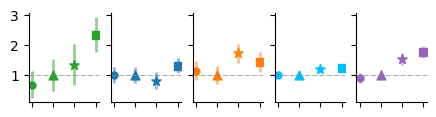

In [74]:
animals = ["molly","eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]

fig, axes = plt.subplots(1,len(animals), figsize=(5, 1.8), sharey = True)


future_all = []
prev_reward_all = []

dt = 0.38
dx= 0.05

ax = axes
animal_ind = 0
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                     minimum_duration = minimum_duration, min_posterior= min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
            data = pickle.load(file)
    
    features_all, response_all = data["features_all"], data["response_all"]
    X = np.vstack(features_all).astype("int") #reshape
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape
    Y = Y.ravel()

    # data
    chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side = return_arr(X,Y)
    chosen_m, unchosen_m, previous_m, previous_reward_m, future_correct_m, same_side_m, switch_side_m = return_mean(
        chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side)
    chosen_yerr, unchosen_yerr, previous_yerr, previous_reward_yerr, future_correct_yerr, same_side_yerr, switch_side_yerr = return_sd(
        chosen/ previous_m, unchosen/ previous_m, previous/ previous_m, previous_reward/ previous_m, future_correct/ previous_m, same_side/ previous_m, switch_side / previous_m)

    subject = str(animal[0]).upper()
    # axes[animal_ind].plot(np.array([0,1,2,3]) * dt,
    #            np.array([previous_reward_m, previous_m, future_correct_m, chosen_m, ]) / previous_m,
    #            color = color_by_rat[animal], label = 'Rat '+ subject,
    #            )

    
    axes[animal_ind].scatter(np.array([0]) * dt,
               np.array([previous_reward_m]) / previous_m,
               color = color_by_rat[animal], label = 'Rat '+ subject,
               marker = ".", s = 100,)
    axes[animal_ind].scatter(np.array([1]) * dt,
               np.array([previous_m]) / previous_m,
               color = color_by_rat[animal], label = 'Rat '+ subject,
               marker = "^", s = 40,)
    axes[animal_ind].scatter(np.array([2]) * dt,
               np.array([future_correct_m]) / previous_m,
               color = color_by_rat[animal], label = 'Rat '+ subject,
               marker = "*", s = 50,)
    axes[animal_ind].scatter(np.array([3]) * dt,
               np.array([chosen_m, ]) / previous_m,
               color = color_by_rat[animal], label = 'Rat '+ subject,
               marker = "s", s = 40,)

    
    axes[animal_ind].errorbar(np.array([0,1,2,3]) * dt,
                 np.array([previous_reward_m, previous_m, future_correct_m, chosen_m, ])/ previous_m,
                  [previous_reward_yerr, previous_yerr, chosen_yerr, future_correct_yerr],
                  fmt = 'None',
                 color = color_by_rat[animal], linewidth = 2, elinewidth = 2, alpha = 0.5)
    axes[animal_ind].axhline(1, linestyle = "-.", color = "grey", linewidth = 0.5)

    # ax.errorbar(np.array([0,1,2,3,4,5]) * dt + animal_ind * dx,
    #             np.array([previous_reward_m, previous_m, chosen_m, future_correct_m, same_side_m, switch_side_m]) / previous_m,
    #              [previous_reward_yerr, previous_yerr, chosen_yerr, future_correct_yerr, same_side_yerr, switch_side_yerr],
    #              fmt = 'None',
    #             color = color_by_rat[animal], linewidth = 2, elinewidth = 2, alpha = 0.5)

    axes[animal_ind].set_xticks(np.array([0,1,2,3]) * dt)
    axes[animal_ind].set_xticklabels([])
    axes[animal_ind].spines[['right', 'top']].set_visible(False)
    animal_ind += 1

fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 


    
# ax.set_xticklabels(["rewarded past", "immediate past", "immediate next", "future rewarded", "same side", "switch side"],rotation = 45)
# ax.set_ylabel("P(remote content) per CoM")

# ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')
# 
# ax.axhline(1, linestyle = "-.", color = "grey", linewidth = 1)

# plt.suptitle(parameter_name, x = 0.5, y = 1.05)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/remote_tally_proportion_all_animals_{parameter_name}_normalized.pdf"
plt.savefig(file_path,dpi=300,bbox_inches='tight')

In [51]:
import seaborn as sns
from spyglass.shijiegu.changeOfMind import color_by_rat

In [52]:
def return_p_value(rand, q):
    return np.sum(rand >= q) / len(rand)

In [53]:
### plot

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p value for future: 0.117
p value for previously rewarded: 0.976
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p value for future: 0.207
p value for previously rewarded: 0.632
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p value for future: 0.177
p value for previously rewarded: 0.549
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p value for future: 0.012
p value for previously rewarded: 0.39
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
p value for future: 0.0
p value for previously rewarded: 0.903
number of observations by rat:
{'molly': 18.0, 'eliot': 35.0, 'julio': 21.0, 'klein': 135.0, 'lewis': 93.0}


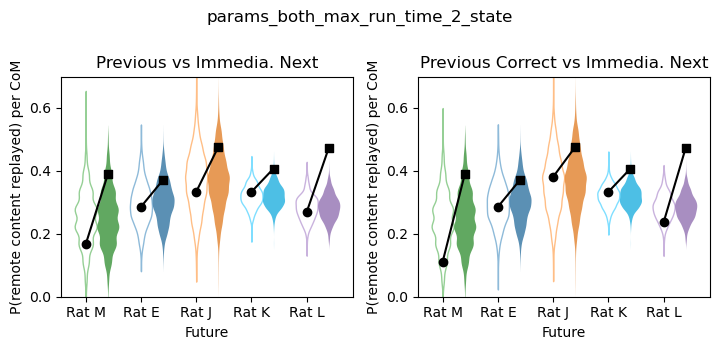

In [54]:
B = 1000
fig, axes = plt.subplots(1,2, figsize=(7, 3))

animals = ["molly","eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]

future_all = []
prev_reward_all = []
com = {}
delta = 0.4 #spacing between 2 violin plots

animal_ind = 0
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                     minimum_duration = minimum_duration, min_posterior= min_posterior, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
            data = pickle.load(file)
    
    features_all, response_all = data["features_all"], data["response_all"]
    X = np.vstack(features_all).astype("int") #reshape
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape
    Y = Y.ravel()

    com[animal] = len(Y) / 4
    
    # data
    chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side = return_probabilities(X,Y)
    # CI
    (chosen_rand, unchosen_rand, previous_rand, previous_reward_rand, future_correct_rand,
     same_side_rand, switch_side_rand) = ([], [], [], [], [], [], [])
    for n in range(B):
        Y_permute = np.random.permutation(Y)
        chosen_, unchosen_, previous_, previous_reward_, future_correct_, same_side_, switch_side_ = return_probabilities(X,Y_permute)
        chosen_rand.append(chosen_)
        unchosen_rand.append(unchosen_)
        previous_rand.append(previous_)
        previous_reward_rand.append(previous_reward_)
        future_correct_rand.append(future_correct_)
        same_side_rand.append(same_side_)
        switch_side_rand.append(switch_side_)
    #violin_dict = {"0": chosen_rand, "1": previous_rand}
    

    xs = np.array([delta]) + (animal_ind)
    df = pd.DataFrame()
    df['Future'] = np.repeat(xs, B)
    df['values'] = (np.array(chosen_rand).reshape((-1,1))).T.flatten()
    sns.violinplot(data=df, x='Future', y='values', ax = axes[1], color = color_by_rat[animal],
               native_scale=True, orient='vertical', inner=None, linewidth=0, width=0.4, alpha = 0.8)

    xs = np.array([0]) + (animal_ind)
    df = pd.DataFrame()
    df['Last trial'] = np.repeat(xs, B)
    df['values'] = np.array(previous_rand).reshape((-1,1)).T.flatten()
    sns.violinplot(data=df, x='Last trial', y='values', ax = axes[1], color = 'white',
               native_scale=True, orient='vertical', inner=None, linewidth=1, width=0.4, linecolor = color_by_rat[animal],
               alpha = 0.5)
    

    axes[0].scatter(0 + animal_ind, previous,color = 'k',zorder = 100)
    axes[0].scatter(delta + animal_ind, chosen,marker='s',color = 'k',zorder = 100)
    axes[0].plot(np.array([0,delta]) + (animal_ind) ,[previous,chosen] ,'k',zorder = 100)
    
    axes[0].set_ylabel("P(remote content replayed) per CoM")


    xs = np.array([delta]) + (animal_ind)
    df = pd.DataFrame()
    df['Future'] = np.repeat(xs, B)
    df['values'] = (np.array(chosen_rand).reshape((-1,1))).T.flatten()
    sns.violinplot(data=df, x='Future', y='values', ax = axes[0], color = color_by_rat[animal],
               native_scale=True, orient='vertical', inner=None, linewidth=0, width=0.4, alpha = 0.8)

    xs = np.array([0]) + (animal_ind)
    df = pd.DataFrame()
    df['Prev Correct'] = np.repeat(xs, B)
    df['values'] = np.array(previous_reward_rand).reshape((-1,1)).T.flatten()
    sns.violinplot(data=df, x='Prev Correct', y='values', ax = axes[0], color = 'white',
               native_scale=True, orient='vertical', inner=None, linewidth=1, width=0.4, linecolor = color_by_rat[animal],
               alpha = 0.5)
    
    axes[1].scatter(0 + animal_ind, previous_reward,color = 'k')
    axes[1].scatter(delta + animal_ind, chosen,marker='s',color = 'k')
    axes[1].plot(np.array([0,delta]) + (animal_ind) ,[previous_reward,chosen] ,'k')
    
    axes[1].set_ylabel("P(remote content replayed) per CoM")

    print(f"p value for future: {return_p_value(chosen_rand, chosen)}")
    print(f"p value for previously rewarded: {return_p_value(previous_reward_rand, previous_reward)}")
    future_all.append(chosen)
    prev_reward_all.append(previous_reward)

    animal_ind += 1


axes[0].set_xticks(np.arange(animal_ind))
axes[0].set_xticklabels(["Rat " + a[0].upper() for a in animals])
axes[0].set_title("Previous vs Immedia. Next")

axes[1].set_xticks(np.arange(animal_ind))
axes[1].set_xticklabels(["Rat " + a[0].upper() for a in animals])
axes[1].set_title("Previous Correct vs Immedia. Next")

axes[0].set_ylim([0,0.7])
axes[0].set_yticks([0,0.2,0.4,0.6])
axes[1].set_ylim([0,0.7])
axes[1].set_yticks([0,0.2,0.4,0.6])


print("number of observations by rat:")
print(com)

plt.suptitle(parameter_name, x = 0.5, y = 1.1)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure5/remote_tally_future_animals_{parameter_name}.pdf"
fig.tight_layout(pad=0.0, w_pad=1, h_pad=0.0) 
plt.savefig(file_path,dpi=300,bbox_inches='tight')

### Fold change plot by rat

In [55]:
import numpy.matlib as ml
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm
from spyglass.shijiegu.changeOfMind_figures.extra_correctness import model2numbers

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
Optimization terminated successfully.
         Current function value: 0.544556
         Iterations 5
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
Optimization terminated successfully.
         Current function value: 0.606916
         Iterations 5
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
Optimization terminated successfully.
         Current function value: 0.650389
         Iterations 4
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM
Optimization terminated successfully.
         Current function value: 0.620624
         Iterations 5
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
Optimization terminated successfully.
         Current function value: 0.569608
         Iterations 5


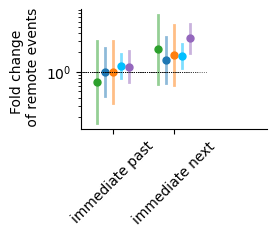

In [56]:
feature_names = ["immediate past",
                 "immediate next"] #"correct future"]
fig, ax1 = plt.subplots(1, 1, figsize=(3.4, 3),
                               sharex = True)

animal_ind = 0 
animals = ["molly", "eliot", "julio", "klein", "lewis"]
for animal in animals:

    """Logistic Regression"""
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                    minimum_duration = minimum_duration, 
                                    min_posterior = min_posterior,
                                    proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]

    # GLM process
    X = np.vstack(features_all).astype("int") #reshape
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape

    feature_dict = {}
    feature_dict["immediate past"] = X[:,0]
    #feature_dict["rewarded past"] = X[:,1]
    feature_dict["immediate next"] = X[:,2]
    #feature_dict["correct future"] = X[:,3]

    np.random.seed(2026)
    x = pd.DataFrame(feature_dict)
    x_ = sm.add_constant(x)
    results = sm.Logit(Y, x_).fit()

    params2, coef_names2, coef_est2, pvalues2, CI2 = model2numbers(results)
    coef_est2 = np.exp(coef_est2)
    CI2 = np.exp(CI2)

    # either
    dt = 0.38
    dx= 0.05
    feature_count = 0
    feature_inds = np.arange(len(coef_names2))[np.isin(feature_names, coef_names2)]
    for axes in [ax1]:
        for ind in feature_inds:
        
            xloc = animal_ind*dx + dt*feature_count
            axes.scatter(xloc, coef_est2[ind], marker = ".", s = 100, color = color_by_rat[animal])
            axes.plot([xloc, xloc], [CI2.iloc[ind][0], CI2.iloc[ind][1]], alpha = 0.5, linewidth = 2, color = color_by_rat[animal])

            feature_count += 1
        # axhline
        axes.axhline(1,-0.1, xloc + .1, color = 'k', linestyle = "dotted", linewidth = 0.5)
        axes.spines[['right', 'top']].set_visible(False)

    ax1.set_xticks(feature_inds * dt + dx * 2)
    ax1.set_xlim([-0.1, xloc +dt + 0.1])
    ax1.set_xticklabels(feature_names, rotation = 45)

    
    ax1.set_ylabel("Fold change \n of remote events")
    ax1.set_yscale('log') 
        
    animal_ind += 1

plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_remote_future_fold_change_by_rat.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [59]:
feature_inds

array([0, 1])

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
Optimization terminated successfully.
         Current function value: 0.555772
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.542978
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.546183
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.561637
         Iterations 5
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
Optimization terminated successfully.
         Current function value: 0.610701
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.610701
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.606917
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.606667
         Iterations 

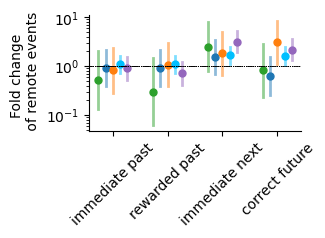

In [66]:
## indivual features
np.random.seed(2026)
feature_names = ["immediate past", "rewarded past", "immediate next", "correct future"]
fig, ax1 = plt.subplots(1, 1, figsize=(3.8,3),
                               sharex = True)
feature_inds = np.array([0,1,2,3])
animal_ind = 0 
animals = ["molly", "eliot", "julio", "klein", "lewis"]
for animal in animals:

    """Logistic Regression"""
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                    minimum_duration = minimum_duration, 
                                    min_posterior = min_posterior,
                                    proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]

    # GLM process
    X = np.vstack(features_all).astype("int") #reshape
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape

    
    for feat_ind in feature_inds:
        feature_dict = {}
        feature_name = feature_names[feat_ind]
        feature_dict[feature_name] = X[:,feat_ind]
    
        x = pd.DataFrame(feature_dict)
        x_ = sm.add_constant(x)
        results = sm.Logit(Y, x_).fit()
    
        params2, coef_names2, coef_est2, pvalues2, CI2 = model2numbers(results)
        coef_est2 = np.exp(coef_est2)
        CI2 = np.exp(CI2)

        # either
        dt = 0.38
        dx=0.05
        for axes in [ax1]:
            xloc = animal_ind*dx + dt * feat_ind
            axes.scatter(xloc, coef_est2[0], marker = ".", s = 100, color = color_by_rat[animal])
            axes.plot([xloc, xloc], [CI2.iloc[0][0], CI2.iloc[0][1]], alpha = 0.5, linewidth = 2, color = color_by_rat[animal])

            feature_count += 1
        # axhline
        axes.axhline(1,-0.1, xloc + .1, color = 'k', linestyle = "dotted", linewidth = 0.5)
        axes.spines[['right', 'top']].set_visible(False)

    ax1.set_xticks(feature_inds * dt + dx * 2)
    ax1.set_xticklabels(feature_names, rotation = 45)

    ax1.set_ylabel("Fold change \n of remote events")
    ax1.set_yscale('log') 
        
    animal_ind += 1

plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_remote_future_fold_change_by_rat2.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

### Merge rats. Mixed logistic regression

In [67]:
import numpy.matlib as ml
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm

In [68]:
np.random.seed(2026)
feature_names = ["previous", "previously_rewarded", "future", "future_correct", "same side", "switch side"]

animal_ind = 0
animals = ["julio","lewis","eliot","molly","klein"]

GLM_x = []
GLM_y = []
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                    minimum_duration = minimum_duration, 
                                    min_posterior = min_posterior,
                                    proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        
    home_replay_all = data["home_replay_all"]
    home_replay_all = data["home_replay_all"]
    features_all, response_all = data["features_all"], data["response_all"]

    # GLM process
    X = np.vstack(features_all).astype("int") #reshape
    X2 = ml.repmat(np.array(home_replay_all).reshape((-1,1)),1,4).reshape((-1,1))
    X = np.hstack((X, X2))
    
    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
    X = np.hstack((X_animal_category, X))

    
    Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape

    GLM_x.append(X)
    GLM_y.append(Y)
    
GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM


In [69]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["rewarded past"] = GLM_x[:,(len(animals)+1)]
feature_dict["immediate past"] = GLM_x[:,len(animals)]
feature_dict["correct future"] = GLM_x[:,(len(animals)+3)]
feature_dict["immediate next"] = GLM_x[:,(len(animals)+2)]

# feature_dict["same side"] = GLM_x[:,(len(animals)+4)]
# feature_dict["switch side"] = GLM_x[:,(len(animals)+5)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit_regularized(method='l1', alpha=0.01, L1_wt=0)

# 3. View the model summary
print(" ===== \n Mixed Logistics \n",logistic_result1.summary())

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     4.519
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.99e-05
Time:                        20:59:28   Log-Likelihood:                -760.59
No. Observations:                1208   AIC:                             1539.
Df Residuals:                    1199   BIC:                             1585.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.2

In [70]:
coef_names = logistic_result1.params.keys()
coef_est = np.exp(np.array(logistic_result1.params))
pvalues = logistic_result1.pvalues
CI = np.exp(logistic_result1.conf_int(alpha=0.05))

coef_names_subset_ind = ["Rat" not in name and "const" not in name for name in coef_names]
coef_names = np.array(coef_names)[coef_names_subset_ind]
coef_est = coef_est[coef_names_subset_ind]
pvalues = pvalues[coef_names_subset_ind]
CI = CI.loc[coef_names]

print(coef_names)
print(pvalues)
print(coef_est)
print(CI)

['rewarded past' 'immediate past' 'correct future' 'immediate next']
rewarded past     0.647248
immediate past    0.352685
correct future    0.088002
immediate next    0.000011
dtype: float64
[1.07928943 1.16159311 1.31458659 1.95986514]
                       0         1
rewarded past   0.778395  1.496496
immediate past  0.846962  1.593104
correct future  0.960106  1.799946
immediate next  1.451018  2.647156


In [71]:
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    coef_names_subset_ind = ["Rat" not in name and "const" not in name for name in coef_names]
    coef_names = np.array(coef_names)[coef_names_subset_ind]
    coef_est = coef_est[coef_names_subset_ind]
    pvalues = pvalues[coef_names_subset_ind]
    CI = CI.loc[coef_names]

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

4.180000000000001 0.03
3.3 0.03
Fold change of the effect of immediate next is 1.959865135588715, with 95% bound: (1.4510179271011596, 2.64715637067962)


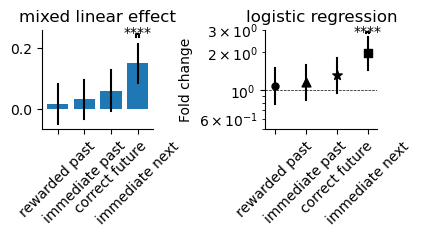

In [72]:
# 4. Create the bar graph using matplotlib

markers = {'rewarded past': ".", "immediate past": "^",
        'immediate next':"s", 'correct future':"*"}
markersizes = {'rewarded past': 100,
               "immediate past": 40,
               'immediate next': 40,
               'correct future': 50}

fig, axes = plt.subplots(1,2,figsize=(5, 3))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes[0].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[0])

axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("mixed linear effect")
axes[0].spines[['right', 'top']].set_visible(False)


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)


for (ind,coef_name) in enumerate(coef_names):
    axes[1].scatter(coef_name, coef_est[ind], color = "k",
                    marker = markers[coef_name], s = markersizes[coef_name])
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("logistic regression")
axes[1].set_ylabel("Fold change")
axes[1].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes[1].set_ylim([0.5,3])
axes[1].set_xlim([-0.3,3.3])
axes[1].set_yscale('log') 

next_point_est = coef_pd.loc["immediate next"]
next_CI = CI.loc["immediate next"]
print(f"Fold change of the effect of immediate next is {next_point_est}, with 95% bound: {next_CI[0],next_CI[1]}")
axes[1].spines[['right', 'top']].set_visible(False)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/remote_mixed_linear_animals_{parameter_name}_{minimum_duration}_{min_posterior}.pdf"
plt.savefig(file_path,dpi=300,bbox_inches='tight')

In [116]:
animal_ind = 0
animals = ["julio","lewis","eliot","molly","klein"]

type_ = "correctness"
GLM_y = []
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                    minimum_duration = minimum_duration, 
                                    min_posterior = min_posterior,
                                    proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
        
    home_replay_all = data["home_replay_all"]
    home_replay_all = data["home_replay_all"]
    features_all, response_all = data["features_all"], data["response_all"]

    if type_ == "correctness":
        Y = [_[-1] for _ in data["tally_dict"]]
        Y = np.array(Y).reshape((-1,1))
        Y = ml.repmat(Y,1,4).reshape((-1,1))
    else:
        Y = np.vstack([np.array(r).reshape((-1,1))for r in response_all]) #reshape

    GLM_y.append(Y)

GLM_y = np.vstack(GLM_y).astype("int")    

julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0.2_p0.1_use1d1_remoteGLM
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0.2_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0.2_p0.1_use1d1_remoteGLM
molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0.2_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0.2_p0.1_use1d1_remoteGLM


### End here

### include home

In [362]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
home = np.array(GLM_x[:,-1]) > 0
feature_dict["rewarded past h"] = np.logical_and(GLM_x[:,(len(animals)+1)] > 0 ,home).astype("int")
feature_dict["immediate past h"] = np.logical_and(GLM_x[:,len(animals)] > 0 ,home).astype("int")
feature_dict["correct future h"] = np.logical_and(GLM_x[:,(len(animals)+3)] > 0 ,home).astype("int")
feature_dict["immediate next h"] = np.logical_and(GLM_x[:,(len(animals)+2)] > 0 ,home).astype("int")

feature_dict["rewarded past nh"] = np.logical_and(GLM_x[:,(len(animals)+1)] > 0 ,~home).astype("int")
feature_dict["immediate past nh"] = np.logical_and(GLM_x[:,len(animals)] > 0 ,~home).astype("int")
feature_dict["correct future nh"] = np.logical_and(GLM_x[:,(len(animals)+3)] > 0 ,~home).astype("int")
feature_dict["immediate next nh"] = np.logical_and(GLM_x[:,(len(animals)+2)] > 0 ,~home).astype("int")
# feature_dict["same side"] = GLM_x[:,(len(animals)+4)]
# feature_dict["switch side"] = GLM_x[:,(len(animals)+5)]



X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit_regularized(method='l1', alpha=0.01, L1_wt=0)

# 3. View the model summary
print(" ===== \n Mixed Logistics \n",logistic_result1.summary())


Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.067
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     7.205
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           7.65e-13
Time:                        09:31:58   Log-Likelihood:                -814.04
No. Observations:                1212   AIC:                             1654.
Df Residuals:                    1199   BIC:                             1720.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const           

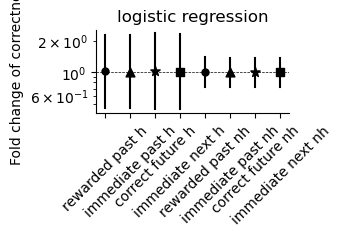

In [364]:
# 4. Create the bar graph using matplotlib

markers = {'rewarded past h': ".", "immediate past h": "^",
        'immediate next h':"s", 'correct future h':"*",
          'rewarded past nh': ".", "immediate past nh": "^",
        'immediate next nh':"s", 'correct future nh':"*"}
markersizes = {'rewarded past h': 100,
               "immediate past h": 40,
               'immediate next h': 40,
               'correct future h': 50,
              'rewarded past nh': 100,
               "immediate past nh": 40,
               'immediate next nh': 40,
               'correct future nh': 50}

fig, axes = plt.subplots(1,1,figsize=(4, 3))

#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)


for (ind,coef_name) in enumerate(coef_names):
    axes.scatter(coef_name, coef_est[ind], color = "k",
                    marker = markers[coef_name], s = markersizes[coef_name])
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')


axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
axes.set_title("logistic regression")
if type_ == "correctness":
    axes.set_ylabel("Fold change of correctness")
else:
    axes.set_ylabel("Fold change of occurence")
axes.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
#axes.set_ylim([0.5,3.1])
#axes.set_xlim([-0.3,3.3])
axes.set_yscale('log') 

axes.spines[['right', 'top']].set_visible(False)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/with_home_remote_mixed_linear_animals_{parameter_name}_{minimum_duration}_{min_posterior}.pdf"
plt.savefig(file_path,dpi=300,bbox_inches='tight')

### same-side vs switch-side GLM

In [54]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["same side"] = GLM_x[:,(len(animals)+4)]
feature_dict["switch side"] = GLM_x[:,(len(animals)+5)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()

print("Mixed Linear Effect \n",ols_result1.summary())

"""b) Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit()

# 3. View the model summary
print(" ===== \n Mixed Logistics \n",logistic_result1.summary())

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.7934
Date:                Sun, 26 Apr 2026   Prob (F-statistic):              0.554
Time:                        08:48:57   Log-Likelihood:                -776.54
No. Observations:                1208   AIC:                             1565.
Df Residuals:                    1202   BIC:                             1596.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1793      

1.98 0.03
1.98 0.03


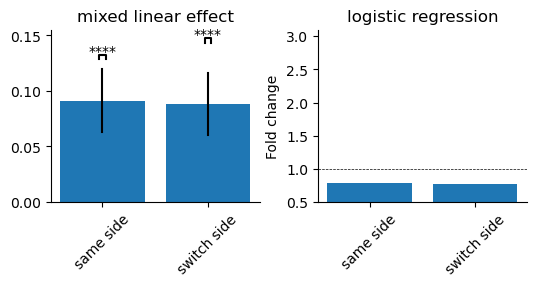

In [55]:
# 4. Create the bar graph using matplotlib

fig, axes = plt.subplots(1,2,figsize=(6, 3.5))

#### axis 0
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
axes[0].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[0].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[0])

axes[0].set_xticks(np.arange(len(coef_names)))
axes[0].set_xticklabels(coef_names, rotation=45)
axes[0].set_title("mixed linear effect")
axes[0].spines[['right', 'top']].set_visible(False)

#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result1)
coef_est = np.exp(coef_est)
coef_pd = np.exp(coef_pd)
CI = np.exp(CI)

axes[1].bar(coef_names, coef_est, error_kw=dict(color='k'))
for coef_name in coef_names:
    axes[1].plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes[1], color = 'k')

axes[1].set_xticks(np.arange(len(coef_names)))
axes[1].set_xticklabels(coef_names, rotation=45)
axes[1].set_title("logistic regression")
axes[1].set_ylabel("Fold change")
axes[1].axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
axes[1].set_ylim([0.5,3.1])
#axes[1].set_yscale('log') 

axes[1].spines[['right', 'top']].set_visible(False)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/sidedness_mixed_linear_animals_{parameter_name}_{minimum_duration}_{min_posterior}.pdf"
plt.savefig(file_path,dpi=300,bbox_inches='tight')


In [278]:
np.mean(Y[X[:,3] == 0]) #chosen

0.06666666666666667

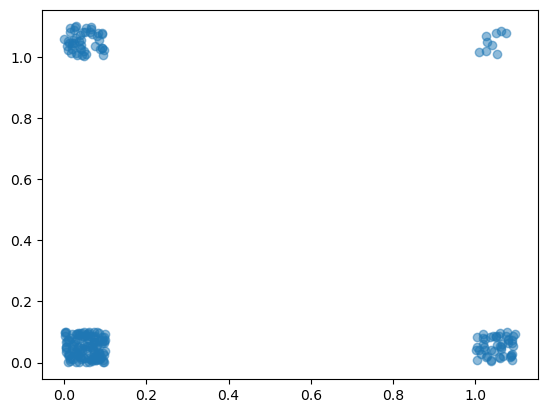

In [273]:
plt.scatter(X[:,1] + np.random.rand(len(X[:,1])) * 0.1,
            Y+ np.random.rand(len(Y)) * 0.1, alpha = 0.5)

### End here

In [ ]:


# Plotting
fig, ax = plt.subplots(figsize=(4, 3))

# Plot coefficients as points
ax.scatter(results_df.index, results_df['coef'], color='blue', zorder=2, label='Coefficient Estimates')

# Plot confidence intervals as error bars or lines
for i, row in results_df.iterrows():
    ax.plot([row.name, row.name], [row['lower_ci'], row['upper_ci']], color='red', linestyle='-', linewidth=2, zorder=1)
    ax.scatter(row.name, row['lower_ci'], marker='_', s=100, color='red', zorder=1)
    ax.scatter(row.name, row['upper_ci'], marker='_', s=100, color='red', zorder=1)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8) # Reference line at zero
ax.set_ylabel('Coefficient Value')
ax.set_title('Beta Coefficient Confidence Intervals')
#ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Playground

In [59]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess

In [216]:
animal = "molly"

In [217]:
tally_dict = find_choice_animal(animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = proportion, use_1d = use_1d)
features_all, response_all = trial_to_features(tally_dict, seq_animals[animal], proportion = 0.1)
# the 4 features are: "previous", "previously_rewarded", "future", "future_correct"

data = {}
data["features_all"] = features_all
data["response_all"] = response_all
data["tally_dict"] = tally_dict
output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
filename = return_save_name(animal, encoding_set_animals[animal], classifier_param_name_animals[animal],
                            list_of_days_animals[animal][0], list_of_days_animals[animal][1], proportion = 0.1, use_1d = 1)
file_path = output_folder + save_name + '.pkl'
with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)

[2025-10-22 16:42:46,571][WARNING]: Skipped checksum for file with hash: a7f7230d-1535-6d65-8122-99efa6798ba1, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_3U0LZRGNTB.nwb


Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_20220420_p0.1_use1d1.pkl':


[16:42:56][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:42:56,602][WARNING]: Skipped checksum for file with hash: 1ae93bab-797d-936b-3347-61a480cfaea3, and path: /stelmo/nwb/analysis/molly20220417_4K9VV4J7CT.nwb
[2025-10-22 16:42:56,615][WARNING]: Skipped checksum for file with hash: 482a386f-3996-4ad9-b554-4a671accab37, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_G9DDV645VV.nwb
[2025-10-22 16:42:56,635][WARNING]: Skipped checksum for file with hash: 1ae93bab-797d-936b-3347-61a480cfaea3, and path: /stelmo/nwb/analysis/molly20220417_4K9VV4J7CT.nwb
[2025-10-22 16:42:56,642][WARNING]: Skipped checksum for file with hash: 1ae93bab-797d-936b-3347-61a480cfaea3, and path: /stelmo/

parsing multiple change of mind


[16:43:52][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:43:52,423][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/nwb/analysis/molly20220417_YLQ61DBELB.nwb
[2025-10-22 16:43:52,437][WARNING]: Skipped checksum for file with hash: ff850b27-3a42-14b3-5b37-ec5a9e356cc0, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_2ILN6BMCX7.nwb
[2025-10-22 16:43:52,458][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/nwb/analysis/molly20220417_YLQ61DBELB.nwb
[2025-10-22 16:43:52,463][WARNING]: Skipped checksum for file with hash: 646b67b5-fc8d-1d8a-edc8-12ee02ca486c, and path: /stelmo/

parsing multiple change of mind


[16:44:19][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:44:19,775][WARNING]: Skipped checksum for file with hash: 6662320b-7a61-3639-cf90-503546a29cfa, and path: /stelmo/nwb/analysis/molly20220418_WXAGS2DXPM.nwb
[2025-10-22 16:44:19,788][WARNING]: Skipped checksum for file with hash: f692bf5f-cf2b-45d6-d4df-e423befe63e2, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_R7EIZ4YEHP.nwb
[2025-10-22 16:44:19,808][WARNING]: Skipped checksum for file with hash: 6662320b-7a61-3639-cf90-503546a29cfa, and path: /stelmo/nwb/analysis/molly20220418_WXAGS2DXPM.nwb
[2025-10-22 16:44:19,814][WARNING]: Skipped checksum for file with hash: 6662320b-7a61-3639-cf90-503546a29cfa, and path: /stelmo/

parsing multiple change of mind


[16:45:18][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:45:18,986][WARNING]: Skipped checksum for file with hash: 0b488a03-64e6-fca8-695d-f7d1d4575273, and path: /stelmo/nwb/analysis/molly20220419_ZTITQPKJ5X.nwb
[2025-10-22 16:45:19,000][WARNING]: Skipped checksum for file with hash: b3e6d9cf-569e-3726-6bbc-9986ee208a60, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_I8NJO669C4.nwb
[2025-10-22 16:45:19,021][WARNING]: Skipped checksum for file with hash: 0b488a03-64e6-fca8-695d-f7d1d4575273, and path: /stelmo/nwb/analysis/molly20220419_ZTITQPKJ5X.nwb
[2025-10-22 16:45:19,026][WARNING]: Skipped checksum for file with hash: 0b488a03-64e6-fca8-695d-f7d1d4575273, and path: /stelmo/

In [201]:
features_all, response_all = trial_to_features(tally_dict, seq_animals[animal], proportion = 0.1)

[2025-10-22 16:32:18,980][WARNING]: Skipped checksum for file with hash: 6d15f446-1984-2674-6897-0e6a64f753db, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_DYWTT7D99X.nwb
[16:32:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:32:29,048][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2025-10-22 16:32:29,068][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a6529963d90, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_9OUQSQKSE7.nwb
[2025-10-22 16:32:29,073][WARNING]: Skipped checksum for file with hash: 0f891b0b-3eb3-416a-2ada-3a65

parsing multiple change of mind
parsing multiple change of mind


[16:32:38][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:32:38,833][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-22 16:32:38,852][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-22 16:32:38,859][WARNING]: Skipped checksum for file with hash: 81f05635-320a-3aa8-f94e-87a8c89b9b2c, and path: /stelmo/nwb/analysis/lewis20240105/lewis20240105_V9VFCR92YP.nwb
[2025-10-22 16:32:38,953][WARNING]: Skipped checksum for file with hash: 8fca837d-dec5-5610-eb71-c7ec

parsing multiple change of mind
parsing multiple change of mind


[16:33:13][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:33:13,209][WARNING]: Skipped checksum for file with hash: 0237c3f0-990c-b881-2dd7-af2225257b3e, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_5QVU4UKMZD.nwb
[2025-10-22 16:33:13,225][WARNING]: Skipped checksum for file with hash: 0237c3f0-990c-b881-2dd7-af2225257b3e, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_5QVU4UKMZD.nwb
[2025-10-22 16:33:13,229][WARNING]: Skipped checksum for file with hash: 0237c3f0-990c-b881-2dd7-af2225257b3e, and path: /stelmo/nwb/analysis/lewis20240106/lewis20240106_5QVU4UKMZD.nwb
[2025-10-22 16:33:13,312][WARNING]: Skipped checksum for file with hash: cdcd57bb-8199-b489-d773-4f95

...

parsing multiple change of mind
parsing multiple change of mind


[16:35:31][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:35:31,752][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-22 16:35:31,771][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-22 16:35:31,776][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f82eb77e0, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_BBPO58S8KF.nwb
[2025-10-22 16:35:31,909][WARNING]: Skipped checksum for file with hash: 7f5489c8-88f7-858f-7260-a1d1

parsing multiple change of mind
parsing multiple change of mind


[16:35:41][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 16:35:41,100][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2025-10-22 16:35:41,118][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb
[2025-10-22 16:35:41,124][WARNING]: Skipped checksum for file with hash: 639c2f29-6f35-8eb0-ea11-7ee6be577699, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_6K2WVTTBUQ.nwb


parsing multiple change of mind
parsing multiple change of mind


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  224
Model:                            GLM   Df Residuals:                      219
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -121.85
Date:                Wed, 22 Oct 2025   Deviance:                       243.71
Time:                        16:39:27   Pearson chi2:                     224.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.03602
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6071      0.232     -2.611      0.009      -1.063      -0.151
x1            -0.3968      0.420     -0.945      0.345      -1.220       0.426
x2            -0.7895      0.436     -1.811      0.070      -1.644       0.065
x3            -0.6592      0.433     -1.522      0.128      -1.508       0.189
x4            -0.3337      0.424     -0.788      0.431      -1.164       0.497
==============================================================================
"""

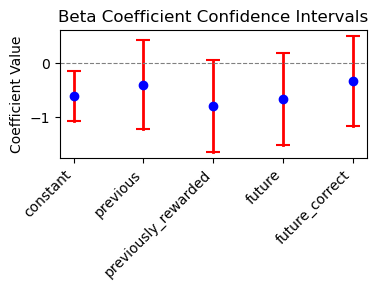

In [214]:
m = model['fit']
conf_int = m.conf_int(alpha=0.05) # 95% confidence interval
coefs = m.params

# Create a DataFrame for easier plotting (optional but good practice)
results_df = pd.DataFrame({
        'coef': coefs,
        'lower_ci': conf_int[:, 0],
        'upper_ci': conf_int[:, 1]
    }, index=["constant", "previous", "previously_rewarded", "future", "future_correct"]) # Adjust index names as per your model

# Plotting
fig, ax = plt.subplots(figsize=(4, 3))

# Plot coefficients as points
ax.scatter(results_df.index, results_df['coef'], color='blue', zorder=2, label='Coefficient Estimates')

# Plot confidence intervals as error bars or lines
for i, row in results_df.iterrows():
    ax.plot([row.name, row.name], [row['lower_ci'], row['upper_ci']], color='red', linestyle='-', linewidth=2, zorder=1)
    ax.scatter(row.name, row['lower_ci'], marker='_', s=100, color='red', zorder=1)
    ax.scatter(row.name, row['upper_ci'], marker='_', s=100, color='red', zorder=1)

ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8) # Reference line at zero
ax.set_ylabel('Coefficient Value')
ax.set_title('Beta Coefficient Confidence Intervals')
#ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [196]:
X.shape

(224, 4)

In [193]:
model = do_GLM_subprocess(np.hstack((X[:,:2],X[:,3:],Y)))

In [194]:
model['fit'].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                      y   No. Observations:                  224
Model:                            GLM   Df Residuals:                      220
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -123.08
Date:                Wed, 22 Oct 2025   Deviance:                       246.15
Time:                        16:18:02   Pearson chi2:                     224.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.02545
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7238      0.221     -3.276      0.001      -1.157      -0.291
x1            -0.3038      0.417     -0.729      0.466      -1.121       0.513
x2            -0.7687      0.436     -1.763      0.078      -1.623       0.086
x3            -0.5755      0.394     -1.462      0.144      -1.347       0.196
==============================================================================
"""

In [172]:
tally_dict[('lewis20240105_.nwb', '02_Rev2Session1',98)]

[(array([1.70448251e+09, 1.70448251e+09]), 2),
 (array([1.70448251e+09, 1.70448251e+09]), 3),
 (array([1.70448251e+09, 1.70448251e+09]), 2),
 (array([1.70448251e+09, 1.70448251e+09]), 3)]

In [42]:
arm_identities_animal

[[2, 2, 2],
 [2, 2],
 [1],
 [1],
 [2],
 [2, 2, 2, 2, 3],
 [2, 2, 2, 2, 3],
 [2],
 [2, 2],
 [2],
 [2, 2],
 [2],
 [2, 2],
 [2],
 [3, 3, 3],
 [2],
 [3],
 [3],
 [0, 4],
 [3, 4, 2, 2],
 [1],
 [4, 2, 4, 2],
 [2],
 [4, 4, 2],
 [2],
 [4, 4],
 [3],
 [3],
 [2],
 [2],
 [2],
 [2, 2],
 [2, 2],
 [2],
 [2],
 [0],
 [3, 2],
 [2],
 [2, 2],
 [2, 2, 2],
 [2, 2, 2, 2, 2, 2, 2],
 [2],
 [3],
 [2],
 [2, 2, 2],
 [2],
 [0],
 [0, 0],
 [4],
 [2, 2],
 [2, 2, 2, 2, 2, 3],
 [4],
 [2],
 [2],
 [2, 2],
 [2, 2],
 [4, 4],
 [2, 2, 2, 2],
 [1, 1]]

In [41]:
info_animal

[['lewis20240105_.nwb', '02_Rev2Session1', [42, 42, 42]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [50, 50]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [70]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '04_Rev2Session2', [9]],
 ['lewis20240105_.nwb', '06_Rev2Session3', [22, 22]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [16]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [20, 20]],
 ['lewis20240106_.nwb', '02_Rev2Session1', [39]],
 ['lewis20240106_.nwb', '04_Rev2Session2', [71, 71]],
 ['lewis20240106_.nwb', '06_Rev2Session3', [44]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [13, 13, 13]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [18]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '06_Rev2Sessi

In [175]:
tally_dict

{('lewis20240105_.nwb',
  '02_Rev2Session1',
  42): [(0, array([1.70448095e+09, 1.70448095e+09]), 2)],
 ('lewis20240105_.nwb',
  '02_Rev2Session1',
  50): [(0, array([1.70448114e+09, 1.70448114e+09]), 2)],
 ('lewis20240105_.nwb',
  '02_Rev2Session1',
  66): [(0, array([1.70448157e+09, 1.70448157e+09]), 1),
  (1, array([1.70448157e+09, 1.70448157e+09]), 1)],
 ('lewis20240105_.nwb',
  '02_Rev2Session1',
  70): [(0, array([1.70448169e+09, 1.70448169e+09]), 2)],
 ('lewis20240105_.nwb',
  '02_Rev2Session1',
  98): [(0, array([1.70448251e+09, 1.70448251e+09]), 2),
  (0, array([1.70448251e+09, 1.70448251e+09]), 3),
  (1, array([1.70448251e+09, 1.70448251e+09]), 2),
  (1, array([1.70448251e+09, 1.70448251e+09]), 3)],
 ('lewis20240105_.nwb',
  '04_Rev2Session2',
  9): [(0, array([1.70448525e+09, 1.70448525e+09]), 2)],
 ('lewis20240105_.nwb',
  '06_Rev2Session3',
  22): [(0, array([1.70448949e+09, 1.70448949e+09]), 2)],
 ('lewis20240105_.nwb',
  '08_Rev2Session4',
  16): [(0, array([1.70449394e+

In [6]:
from spyglass.shijiegu.load import load_decode
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd
from spyglass.shijiegu.Analysis_SGU import get_linearization_map
from spyglass.common.common_position import TrackGraph, IntervalLinearizedPosition, IntervalPositionInfo

In [16]:
animal = "lewis"

In [17]:
loaded_data = load_remote_animal_figure4(
        animal, list_of_days_animals[animal],
        encoding_set_animals[animal],
        classifier_param_name_animals[animal],
        proportion = proportion, use_1d = use_1d)
    
(all_info_animal, info_animal,
     time_intervals_animal, arm_identities_animal
        ) = (loaded_data['all_info_animal'], loaded_data['info_animal'],
             loaded_data['time_intervals_animal'], loaded_data['arm_identities_animal'])

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240110_p0.1_use1d1.pkl':


In [135]:
time_intervals_animal

[[array([1.70448095e+09, 1.70448095e+09]),
  array([1.70448095e+09, 1.70448095e+09]),
  array([1.70448095e+09, 1.70448095e+09])],
 [array([1.70448114e+09, 1.70448114e+09]),
  array([1.70448114e+09, 1.70448114e+09])],
 [array([1.70448157e+09, 1.70448157e+09])],
 [array([1.70448157e+09, 1.70448157e+09])],
 [array([1.70448169e+09, 1.70448169e+09])],
 [array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09])],
 [array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09]),
  array([1.70448251e+09, 1.70448251e+09])],
 [array([1.70448525e+09, 1.70448525e+09])],
 [array([1.70448949e+09, 1.70448949e+09]),
  array([1.70448949e+09, 1.70448949e+09])],
 [array([1.70449394e+09, 1.70449394e+09])],
 [array([1.70449407e+09, 1.70449407e+09]),
 

In [32]:
info_animal

[['lewis20240105_.nwb', '02_Rev2Session1', [42, 42, 42]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [50, 50]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [66]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [70]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '02_Rev2Session1', [98, 98, 98, 98, 98]],
 ['lewis20240105_.nwb', '04_Rev2Session2', [9]],
 ['lewis20240105_.nwb', '06_Rev2Session3', [22, 22]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [16]],
 ['lewis20240105_.nwb', '08_Rev2Session4', [20, 20]],
 ['lewis20240106_.nwb', '02_Rev2Session1', [39]],
 ['lewis20240106_.nwb', '04_Rev2Session2', [71, 71]],
 ['lewis20240106_.nwb', '06_Rev2Session3', [44]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [13, 13, 13]],
 ['lewis20240106_.nwb', '08_Rev2Session4', [18]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '02_Rev2Session1', [47]],
 ['lewis20240107_.nwb', '06_Rev2Sessi

In [33]:
arm_identities_animal

[[2, 2, 2],
 [2, 2],
 [1],
 [1],
 [2],
 [2, 2, 2, 2, 3],
 [2, 2, 2, 2, 3],
 [2],
 [2, 2],
 [2],
 [2, 2],
 [2],
 [2, 2],
 [2],
 [3, 3, 3],
 [2],
 [3],
 [3],
 [0, 4],
 [3, 4, 2, 2],
 [1],
 [4, 2, 4, 2],
 [2],
 [4, 4, 2],
 [2],
 [4, 4],
 [3],
 [3],
 [2],
 [2],
 [2],
 [2, 2],
 [2, 2],
 [2],
 [2],
 [0],
 [3, 2],
 [2],
 [2, 2],
 [2, 2, 2],
 [2, 2, 2, 2, 2, 2, 2],
 [2],
 [3],
 [2],
 [2, 2, 2],
 [2],
 [0],
 [0, 0],
 [4],
 [2, 2],
 [2, 2, 2, 2, 2, 3],
 [4],
 [2],
 [2],
 [2, 2],
 [2, 2],
 [4, 4],
 [2, 2, 2, 2],
 [1, 1]]

In [162]:
arm_identities_animal[16]

[3]

In [163]:
arm_identities_animal[17]

[3]

In [156]:
ind = 50

In [157]:
print(info_animal[ind], arm_identities_animal[ind])

['lewis20240110_.nwb', '04_Rev2Session2', [17, 17, 17, 17, 17, 17]] [2, 2, 2, 2, 2, 3]


In [158]:
nwb_copy_file_name, session_name, trialID = info_animal[ind]


# 1.
decode = load_decode(nwb_copy_file_name,session_name,'default_decoding_gpu_4armMaze','2Dheadspeed_above_4')
position_axis = np.array(decode.coords['position'])

In [159]:
q = {"nwb_file_name": nwb_copy_file_name,
        "epoch":int(session_name[:2]),
        "proportion":str(proportion)}
    
log_df = ChangeofMind().fetch1_dataframe(q)

[2025-10-22 11:03:07,011][WARNING]: Skipped checksum for file with hash: 4966fca3-5add-6507-a578-c07eca58e93d, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_YVZ4HOMCDS.nwb


In [160]:
log_df[log_df.change_of_mind]

,timestamp_H,Home,timestamp_O,OuterWellIndex,rewardNum,change_of_mind,CoMMaxProportion,initial_choice,initial_time,proportion_arm1,proportion_arm2,proportion_arm3,proportion_arm4,CoMNum_by_time,CoMNum_by_arm,current,future_H,future_O,past,past_reward
id,,,,,,,,,,,,,,,,,,,,
12,1.704916e+09,1.0,1.704916e+09,1.0,2.0,True,0.782806,4.0,1.704916e+09,0.000000,0.782806,0.000000,0.165771,4,2,1.0,1.0,3.0,3.0,3.0
15,1.704916e+09,1.0,1.704916e+09,2.0,2.0,True,0.435658,1.0,1.704916e+09,0.435658,0.000000,0.000000,0.000000,1,1,2.0,2.0,4.0,4.0,1.0
17,1.704916e+09,1.0,1.704916e+09,3.0,2.0,True,0.976399,1.0,1.704916e+09,0.976399,0.000000,0.000000,0.000000,1,1,3.0,3.0,1.0,4.0,4.0
18,1.704916e+09,1.0,1.704916e+09,1.0,2.0,True,0.106597,2.0,1.704916e+09,0.000000,0.106597,0.000000,0.000000,1,1,1.0,1.0,2.0,3.0,3.0
22,1.704916e+09,1.0,1.704916e+09,1.0,2.0,True,0.957479,2.0,1.704916e+09,0.000000,0.957479,0.000000,0.000000,1,1,1.0,1.0,4.0,3.0,3.0
24,1.704916e+09,1.0,1.704916e+09,2.0,2.0,True,0.768637,2.0,1.704916e+09,0.000000,0.294092,0.768637,0.000000,2,2,2.0,2.0,4.0,4.0,1.0
26,1.704916e+09,1.0,1.704916e+09,3.0,2.0,True,0.448639,1.0,1.704916e+09,0.448639,0.334019,0.000000,0.000000,2,2,3.0,3.0,4.0,4.0,4.0
29,1.704916e+09,1.0,1.704916e+09,2.0,2.0,True,0.790893,4.0,1.704916e+09,0.000000,0.000000,0.000000,0.790893,1,1,2.0,2.0,4.0,1.0,1.0
35,1.704916e+09,1.0,1.704916e+09,4.0,2.0,True,0.131716,3.0,1.704916e+09,0.000000,0.000000,0.131716,0.000000,1,1,4.0,4.0,3.0,2.0,2.0


In [46]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import arm_to_features

In [48]:
arm_to_features(np.array([1,2,3,4]),feature_dict = {"recent":1,
                        "recent_reward":4,
                        "final_choice":2,
                        "future_correct":2})

(array([[ True, False, False, False],
        [False, False,  True,  True],
        [False, False, False, False],
        [False,  True, False, False]]),
 [array(False), array(True), array(True), array(True)])

In [339]:
t0, t1 = time_intervals_animal[ind][0]

timestamp_H         1704837183.325913
Home                              1.0
timestamp_O         1704837204.335067
OuterWellIndex                    4.0
rewardNum                         2.0
change_of_mind                   True
CoMMaxProportion             0.828244
initial_choice                    1.0
initial_time        1704837192.212236
proportion_arm1              0.306349
proportion_arm2              0.828244
proportion_arm3                   0.0
proportion_arm4                   0.0
CoMNum_by_time                      3
CoMNum_by_arm                       2
current                           4.0
future_H                          4.0
future_O                          1.0
past                              3.0
past_reward                       2.0
Name: 14, dtype: object

In [177]:
# 2. get decode and animal head direction
position_name = session2position_name(nwb_copy_file_name, session_name)
position_info = (IntervalPositionInfo() & {
                'nwb_file_name':nwb_copy_file_name,
                'interval_list_name':position_name,
                'position_info_param_name':'default_decoding'}).fetch1_dataframe()
position_info1d = (IntervalLinearizedPosition() & {
                'nwb_file_name':nwb_copy_file_name,
                'interval_list_name':position_name,
                'position_info_param_name':'default_decoding'}).fetch1_dataframe() #for debug use only


[2025-10-22 14:56:53,290][WARNING]: Skipped checksum for file with hash: 7c7e9aea-6b5b-6d44-d2b7-9e5dc7d8f455, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_KEQJO0PVHX.nwb
[2025-10-22 14:56:53,311][WARNING]: Skipped checksum for file with hash: 7c7e9aea-6b5b-6d44-d2b7-9e5dc7d8f455, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_KEQJO0PVHX.nwb
[2025-10-22 14:56:53,318][WARNING]: Skipped checksum for file with hash: 7c7e9aea-6b5b-6d44-d2b7-9e5dc7d8f455, and path: /stelmo/nwb/analysis/lewis20240110/lewis20240110_KEQJO0PVHX.nwb
[14:57:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
	IntervalLinearizedPosition -> spyglass.linearization.v0.main.IntervalLinearizedPosition
Please use the new location.
[2025-10-22 14:57:02,891][WARNING]: Skipped checksum for file with hash: 6ba48a1e-2633-a8e4-fe68-928f

In [178]:
position_info1d

,linear_position,track_segment_id,projected_x_position,projected_y_position
time,,,,
1.704916e+09,NaN,0,NaN,NaN
1.704916e+09,NaN,0,NaN,NaN
1.704916e+09,NaN,0,NaN,NaN
1.704916e+09,NaN,0,NaN,NaN
1.704916e+09,NaN,0,NaN,NaN
...,...,...,...,...
1.704918e+09,88.745248,1,215.631138,145.424391
1.704918e+09,88.721903,1,215.630102,145.447714
1.704918e+09,88.698557,1,215.629065,145.471036


In [331]:
# 4. Get animal head direction
head_orientation = np.array(pos2d_subset.head_orientation)
head_orientation_unit = np.hstack((np.cos(head_orientation).reshape((-1,1)),np.sin(head_orientation).reshape((-1,1)))) #unit vector

# Get max_posterior_2d - animal location
animal_location = np.hstack((np.array(pos2d_subset.head_position_x).reshape(-1,1),np.array(pos2d_subset.head_position_y).reshape(-1,1)))
displacement_unit = max_posterior_2d - animal_location
displacement_unit = displacement_unit / np.linalg.norm(displacement_unit, axis = 1).reshape((-1,1))

# finally: return degree
dot_product = [np.dot(head_orientation_unit[i],displacement_unit[i].T) for i in range(displacement_unit.shape[0])]
angle = np.degrees(np.arccos(np.clip(dot_product, -1.0, 1.0)))



In [332]:
angle

array([14.44713613, 14.48218834, 14.51722652, 14.55225064, 14.5872607 ,
       14.62225669, 14.65723861, 14.69220645, 14.72716019, 14.76209984,
       14.79702538, 14.83193681, 14.86683412, 14.90171729, 14.93658634,
       14.97144174, 15.00648324, 15.07571997, 15.11071878, 15.14550336,
       15.18027325, 15.21502896, 15.24977046, 15.28449776, 15.31921085,
       15.35390973, 15.38859437, 14.52662663, 12.62564912, 11.61687587])

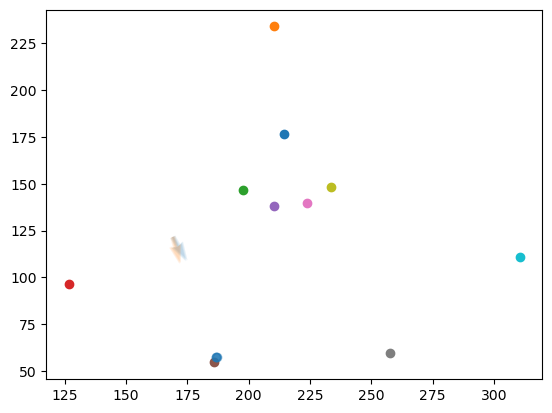

In [334]:
fig, ax = plt.subplots()

for key in nodes:
     node = nodes[key]
     for n in node:
         ax.scatter(n[0],n[1])
ax.scatter(max_posterior_2d[::10,0] + np.random.rand(len(max_posterior_2d[::10,0]))*.1,
            max_posterior_2d[::10,1] + + np.random.rand(len(max_posterior_2d[::10,0]))*.1, alpha = 0.5)

ax.quiver(animal_location[::10,0],animal_location[::10,1],
           head_orientation_unit[::10,0],head_orientation_unit[::10,1],color = 'C0',alpha = 0.1)
ax.quiver(animal_location[::10,0],animal_location[::10,1],
           displacement_unit[::10,0],displacement_unit[::10,1],color = 'C1',alpha = 0.1)


# Invert the y-axis (make it upside down)
#ax.invert_yaxis()

In [ ]:
animal = "lewis"
list_of_days = ['20240105','20240109',
                 '20240110']
tally_dict = find_choice_animal(animal, list_of_days,
            encoding_set_animals[animal],
            classifier_param_name_animals[animal],
            proportion = proportion, use_1d = use_1d)
features_all, response_all, info_all = trial_to_features(tally_dict, seq_animals[animal],
                                               proportion = 0.1, debug = True)

i = 34
print(response_all[i])
print(features_all[i])
print(info_all[i])
nwb_copy_file_name, session_name, trialID, arm = info_all[i]
 #"previous", "previously_rewarded", "future", "future_correct"

log_df.loc[trialID - 3:trialID]


q = {"nwb_file_name": nwb_copy_file_name,
     "epoch":int(session_name[:2]),
     "proportion":str(proportion)}
                
log_df = ChangeofMind().fetch1_dataframe(q)

array([225.12560103, 136.2734064 ])

In [ ]:
#plt.plot(max_posterior_1d)
for key in nodes:
    node = nodes[key]
    for n in node:
        plt.scatter(n[0],n[1])
plt.scatter(max_posterior_2d[:,0], max_posterior_2d[:,1])